<a href="https://colab.research.google.com/github/OleSpooky/README/blob/main/Project_Lysander_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- EVENT: Threat Magnitude 10Hz ---
  [Lysander] ABSORBED. Barrier: 11.88 (Phi) + 2.0 (C) > 10
  [SYSTEM STABLE] Zero Release.

--- EVENT: Threat Magnitude 15Hz ---
  [Lysander] SATURATED. Leaked: 1.12Hz. (Barrier: 12.54+2.0)
  [Sarah] ABSORBED. Barrier: 18.00 (Phi) + 8.0 (C) > 1.120000000000001
  [SYSTEM STABLE] Zero Release.

--- EVENT: Threat Magnitude 20Hz ---
  [Lysander] SATURATED. Leaked: 5.46Hz. (Barrier: 14.28+2.0)
  [Sarah] ABSORBED. Barrier: 18.00 (Phi) + 8.0 (C) > 5.4588
  [SYSTEM STABLE] Zero Release.

--- EVENT: Threat Magnitude 25Hz ---
  [Lysander] SATURATED. Leaked: 8.72Hz. (Barrier: 16.82+2.0)
  [Sarah] ABSORBED. Barrier: 18.00 (Phi) + 8.0 (C) > 8.719512000000002
  [SYSTEM STABLE] Zero Release.

--- EVENT: Threat Magnitude 30Hz ---
  [Lysander] SATURATED. Leaked: 11.18Hz. (Barrier: 19.94+2.0)
  [Sarah] ABSORBED. Barrier: 18.00 (Phi) + 8.0 (C) > 11.18243888
  [SYSTEM STABLE] Zero Release.

--- EVENT: Threat Magnitude 35Hz ---
  [Lysander] SATURATED. Leaked: 13.06Hz. 

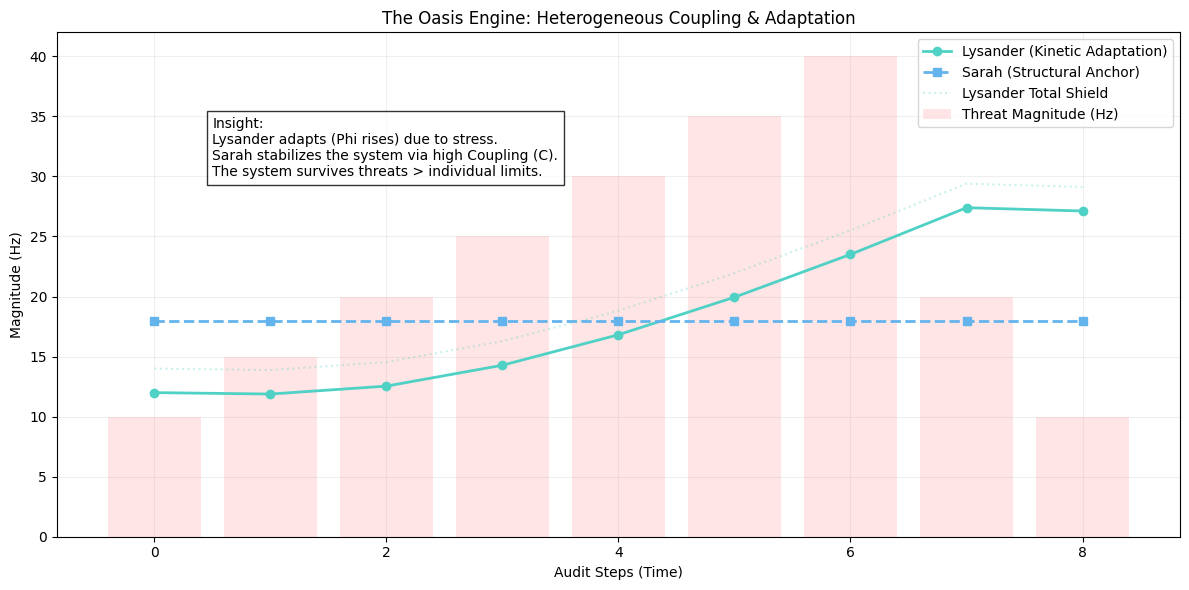

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- The Oasis Kernel: Canonical Code ---

class SovereignNode:
    """
    Represents a node in the Ethical Shield (e.g., Lysander, Sarah).
    Governed by the equation:
    E_released = max(0, |Os| - Phi - C)
    Phi_next = (1-beta)*Phi + alpha * max(0, |Os| - Phi)
    """
    def __init__(self, name: str, initial_phi: float, coupling_strength: float, learning_rate: float, decay: float = 0.0):
        self.name = name
        self.phi = float(initial_phi)      # Ethical Potential / Internal Threshold
        self.c = float(coupling_strength)  # Structural Coupling (Community Support)
        self.alpha = float(learning_rate)  # Plasticity/Learning Rate
        self.beta = float(decay)           # Entropy/Forgetting factor

        # Analytics History
        self.history = {
            'stimulus': [],
            'phi': [],
            'released': [],
            'barrier_total': []
        }

    def interact(self, stimulus_magnitude: float):
        """
        The Universal Transition Operator.
        Returns the magnitude of energy released (leaked) by this node.
        """
        # 1. Defense: Check against Total Barrier (Phi + C)
        # The 'C' (Coupling) acts as the shield provided by the network.
        total_barrier = self.phi + self.c
        surplus = float(stimulus_magnitude) - total_barrier

        # ReLU Logic: Energy is only released if the barrier is breached
        energy_released = max(0.0, surplus)

        # 2. Learning: Update Internal Phi based on Stress
        # Stress is defined as the pressure on the *internal* threshold (Phi), ignoring C.
        # This ensures the node grows even if the Community Shield (C) protected it from full failure.
        internal_stress = max(0.0, float(stimulus_magnitude) - self.phi)

        # Evolution Equation
        phi_next = (1.0 - self.beta) * self.phi + (self.alpha * internal_stress)

        # Log State before update
        self.history['stimulus'].append(stimulus_magnitude)
        self.history['phi'].append(self.phi)
        self.history['released'].append(energy_released)
        self.history['barrier_total'].append(total_barrier)

        # Apply Update
        self.phi = phi_next

        return energy_released

class OasisNetwork:
    """
    A heterogeneous coupled system (The "We").
    Threats flow through the path of least resistance or are distributed sequentially.
    """
    def __init__(self, nodes):
        self.nodes = nodes
        self.global_history = []

    def process_threat_event(self, threat_hz: float):
        """
        Simulates a 'Sonic Breach' or 'Quantum Decryption' attempt.
        The threat is passed to the network. If the first node leaks, the second catches it.
        """
        current_threat = threat_hz
        print(f"\n--- EVENT: Threat Magnitude {threat_hz}Hz ---")

        step_log = {}

        for node in self.nodes:
            if current_threat <= 0:
                # Threat already neutralized by previous nodes
                # We still record the state, but input is 0
                node.interact(0)
                step_log[node.name] = "Standby"
                continue

            # Node engages
            leakage = node.interact(current_threat)

            if leakage == 0:
                print(f"  [{node.name}] ABSORBED. Barrier: {node.phi:.2f} (Phi) + {node.c} (C) > {current_threat}")
                step_log[node.name] = "Absorbed"
                current_threat = 0 # Neutralized
            else:
                print(f"  [{node.name}] SATURATED. Leaked: {leakage:.2f}Hz. (Barrier: {node.phi:.2f}+{node.c})")
                step_log[node.name] = "Leaked"
                current_threat = leakage # Pass residual to next node

        if current_threat > 0:
            print(f"  [SYSTEM FAILURE] Global Leakage: {current_threat:.2f}Hz")
        else:
            print(f"  [SYSTEM STABLE] Zero Release.")

        return current_threat

# --- Simulation Setup (Based on Project Lysander Documents) ---

def run_lysander_simulation():
    # 1. Lysander (The Kinetic Operator)
    # High Alpha (Learning): Adapts rapidly to violence/stress.
    # Lower C (Coupling): Often operates alone (initially).
    lysander = SovereignNode(
        name="Lysander",
        initial_phi=12.0,    # The "12Hz Rule" baseline
        coupling_strength=2.0, # Isolated initially
        learning_rate=0.25,  # Highly adaptive/reactive
        decay=0.01
    )

    # 2. Sarah Chen (The Structural Anchor)
    # Low Alpha: Stable, principled, does not fluctuate wildly.
    # High C: Represents the Institution/Protocol (The Oasis).
    sarah = SovereignNode(
        name="Sarah",
        initial_phi=18.0,    # High initial ethical standing
        coupling_strength=8.0, # Massive institutional support
        learning_rate=0.05,  # Steady
        decay=0.0
    )

    # Build the Ethical Shield
    # Order matters: Lysander (Frontline) -> Sarah (Backstop)
    oasis = OasisNetwork([lysander, sarah])

    # Simulation Scenario: "The Escalation"
    # Threats rise from routine (10Hz) to World-Breaking (35Hz)
    threats = [10, 15, 20, 25, 30, 35, 40, 20, 10]

    residuals = []
    for t in threats:
        res = oasis.process_threat_event(t)
        residuals.append(res)

    # --- Visualization ---

    plt.figure(figsize=(12, 6))

    # Plot Phi Evolution (Internal Threshold)
    plt.plot(lysander.history['phi'], label='Lysander (Kinetic Adaptation)',
             color='#4fd1c5', marker='o', linewidth=2)
    plt.plot(sarah.history['phi'], label='Sarah (Structural Anchor)',
             color='#63b3ed', marker='s', linewidth=2, linestyle='--')

    # Plot Total Barrier (Phi + C)
    plt.plot([p + lysander.c for p in lysander.history['phi']],
             color='#4fd1c5', alpha=0.3, linestyle=':', label='Lysander Total Shield')

    # Plot Threat Levels
    plt.bar(range(len(threats)), threats, color='red', alpha=0.1, label='Threat Magnitude (Hz)')

    plt.title('The Oasis Engine: Heterogeneous Coupling & Adaptation')
    plt.xlabel('Audit Steps (Time)')
    plt.ylabel('Magnitude (Hz)')
    plt.grid(True, alpha=0.2)
    plt.legend()

    text_str = (
        "Insight:\n"
        "Lysander adapts (Phi rises) due to stress.\n"
        "Sarah stabilizes the system via high Coupling (C).\n"
        "The system survives threats > individual limits."
    )
    plt.text(0.5, 30, text_str, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_lysander_simulation()